# Word2vec

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Current device:", torch.cuda.current_device())
else:
    print("Running on CPU")

CUDA available: True
GPU name: NVIDIA GeForce RTX 4080
Current device: 0


In [2]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")
print(df.head())
print(df.columns)

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Index(['review', 'sentiment'], dtype='str')


In [3]:
df = df.dropna()              # clean missing values
df = df.sample(1000, random_state=42)  # take 1k random rows

print(df.shape)
print(df.head())

(1000, 2)
                                                  review sentiment
33553  I really liked this Summerslam due to the look...  positive
9427   Not many television shows appeal to quite as m...  positive
199    The film quickly gets to a major chase scene w...  negative
12447  Jane Austen would definitely approve of this o...  positive
39489  Expectations were somewhat high for me when I ...  negative


# Preprocessing for word2vec

In [4]:
import pandas as pd
import re

df = pd.read_csv("IMDB Dataset.csv")

df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br />", " ", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["clean_text"] = df["review"].apply(clean_text)

# tokenize
sentences = df["clean_text"].apply(lambda x: x.split()).tolist()

# Train word2vec

In [5]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,   # embedding dimension
    window=5,
    min_count=2,
    workers=4,
    sg=1               # 1 = skip-gram, 0 = CBOW
)

w2v_model.save("imdb_word2vec.model")

# View vector of 100 words in embedding space

Word2vsc is high-D. So it is impossible to visualize on 2D. For that we have
its dimenstion by dimension reduction. We use PCA or t-SNE dimension reduction

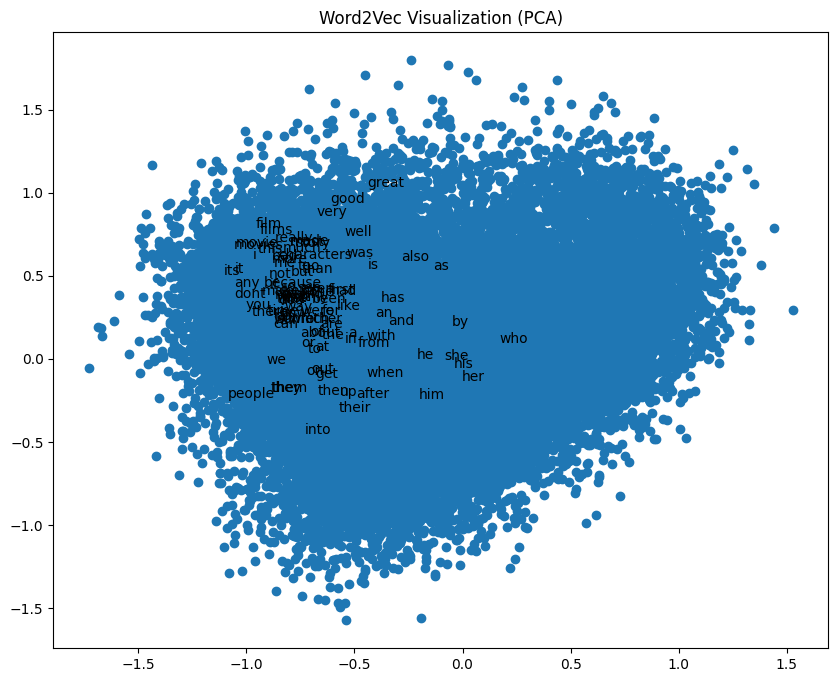

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# get word vectors
words = list(w2v_model.wv.index_to_key)
vectors = np.array([w2v_model.wv[word] for word in words])

# reduce to 2D
pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

# plot
plt.figure(figsize=(10, 8))
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words[:100]):  # plot only first 100 words
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

plt.title("Word2Vec Visualization (PCA)")
plt.show()

## Using t-SNE to view embedding space

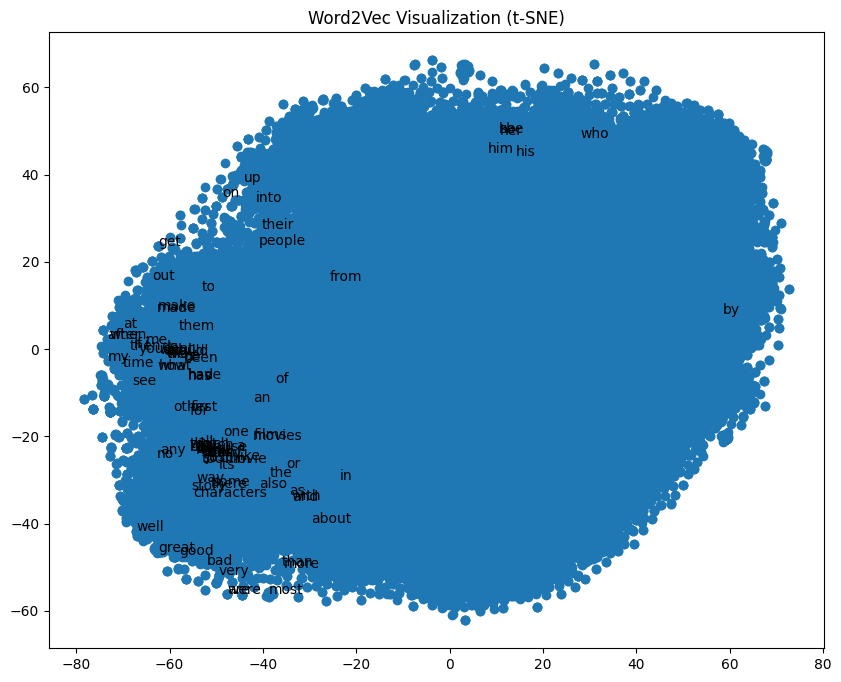

In [7]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

words = list(w2v_model.wv.index_to_key)
vectors = np.array([w2v_model.wv[word] for word in words])

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
result = tsne.fit_transform(vectors)

plt.figure(figsize=(10, 8))
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words[:100]):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

plt.title("Word2Vec Visualization (t-SNE)")
plt.show()

## Converting each review into a single vector
This will change each review to vector. It do so by averaging the vector of each words in the review.
First it extract vector for eeach words in the review. Then average to get vector of the whole review.

In [8]:
import numpy as np

def get_review_vector(words, model, vector_size=100):
    vectors = []
    for w in words:
        if w in model.wv:
            vectors.append(model.wv[w])
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X = np.array([get_review_vector(words, w2v_model) for words in sentences])
y = df["label"].values

# Vector for first 5 reviews 

In [10]:
for words in sentences[:5]:  # first 5 reviews
    vector = get_review_vector(words, w2v_model)
    print("Review:", " ".join(words))
    print("Vector:", vector)
    print()

Review: one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far away i would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget prett

# Logistic Regression

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

print("Accuracy:", clf.score(X_test, y_test))

Accuracy: 0.8681


## weights learned

In [ ]:
# Print all weights at once
print(clf.coef_)

[[ 4.01285232e+00  1.78071567e+00  5.68160315e+00 -4.20006671e+00
   2.81209756e-01  4.39679486e+00  2.64208238e+00 -7.51078895e+00
  -9.38319374e-01 -1.10401686e+01 -2.39472969e+00  1.78761718e+00
  -1.84547858e+00 -2.06578392e+00  1.01361297e+00 -1.40465858e+00
   7.79999448e+00 -6.80875488e+00 -2.23791021e+00 -2.44288204e+00
  -3.63665581e+00  1.60149772e+00 -5.46209777e+00  9.92847185e+00
   1.72341284e+00  3.60327111e+00 -4.32016917e-01  3.33636542e+00
   1.22387992e+00  5.35137846e+00  7.15348613e+00  8.41396482e+00
   3.84726891e-01  4.38207589e+00 -3.40980170e+00  2.86603395e+00
   3.71911158e-02  5.57282006e+00 -4.71016974e+00  4.02815750e+00
   9.38833667e+00  6.39956563e-01  1.21789246e+00 -2.97980079e+00
   3.68570278e+00 -3.15600168e+00  1.10440829e+00  6.29423556e+00
  -6.74407015e+00 -5.44052321e+00  6.03563303e+00  4.52329499e+00
  -2.50391934e+00  4.25365232e-01  4.91485315e+00 -8.80735215e+00
  -1.00543414e+00 -3.53677783e+00  1.76185074e+00 -4.00279264e+00
   7.79459

In [ ]:
# Print one by one
weights = clf.coef_[0]

for i, w in enumerate(weights):
    print(f"x{i}: {w:.4f}")

x0: 4.0129
x1: 1.7807
x2: 5.6816
x3: -4.2001
x4: 0.2812
x5: 4.3968
x6: 2.6421
x7: -7.5108
x8: -0.9383
x9: -11.0402
x10: -2.3947
x11: 1.7876
x12: -1.8455
x13: -2.0658
x14: 1.0136
x15: -1.4047
x16: 7.8000
x17: -6.8088
x18: -2.2379
x19: -2.4429
x20: -3.6367
x21: 1.6015
x22: -5.4621
x23: 9.9285
x24: 1.7234
x25: 3.6033
x26: -0.4320
x27: 3.3364
x28: 1.2239
x29: 5.3514
x30: 7.1535
x31: 8.4140
x32: 0.3847
x33: 4.3821
x34: -3.4098
x35: 2.8660
x36: 0.0372
x37: 5.5728
x38: -4.7102
x39: 4.0282
x40: 9.3883
x41: 0.6400
x42: 1.2179
x43: -2.9798
x44: 3.6857
x45: -3.1560
x46: 1.1044
x47: 6.2942
x48: -6.7441
x49: -5.4405
x50: 6.0356
x51: 4.5233
x52: -2.5039
x53: 0.4254
x54: 4.9149
x55: -8.8074
x56: -1.0054
x57: -3.5368
x58: 1.7619
x59: -4.0028
x60: 0.7795
x61: 8.6731
x62: 11.8056
x63: -0.4333
x64: 4.1998
x65: 8.1769
x66: 5.5278
x67: 1.4369
x68: 6.6615
x69: -6.4840
x70: -4.2264
x71: -5.0370
x72: -0.0051
x73: -9.6893
x74: 1.6948
x75: -1.4549
x76: -6.1130
x77: -7.7752
x78: 4.4111
x79: -4.3781
x80: 2.2316
x

In [15]:
print(clf.intercept_)

[-2.62975314]


## The equation learned by logistic regression 

In [16]:
weights = clf.coef_[0]
b = clf.intercept_[0]

equation = " + ".join(
    [f"({w:.4f}*x{i})" for i, w in enumerate(weights)]
)

print(f"z = {equation} + ({b:.4f})")

z = (4.0129*x0) + (1.7807*x1) + (5.6816*x2) + (-4.2001*x3) + (0.2812*x4) + (4.3968*x5) + (2.6421*x6) + (-7.5108*x7) + (-0.9383*x8) + (-11.0402*x9) + (-2.3947*x10) + (1.7876*x11) + (-1.8455*x12) + (-2.0658*x13) + (1.0136*x14) + (-1.4047*x15) + (7.8000*x16) + (-6.8088*x17) + (-2.2379*x18) + (-2.4429*x19) + (-3.6367*x20) + (1.6015*x21) + (-5.4621*x22) + (9.9285*x23) + (1.7234*x24) + (3.6033*x25) + (-0.4320*x26) + (3.3364*x27) + (1.2239*x28) + (5.3514*x29) + (7.1535*x30) + (8.4140*x31) + (0.3847*x32) + (4.3821*x33) + (-3.4098*x34) + (2.8660*x35) + (0.0372*x36) + (5.5728*x37) + (-4.7102*x38) + (4.0282*x39) + (9.3883*x40) + (0.6400*x41) + (1.2179*x42) + (-2.9798*x43) + (3.6857*x44) + (-3.1560*x45) + (1.1044*x46) + (6.2942*x47) + (-6.7441*x48) + (-5.4405*x49) + (6.0356*x50) + (4.5233*x51) + (-2.5039*x52) + (0.4254*x53) + (4.9149*x54) + (-8.8074*x55) + (-1.0054*x56) + (-3.5368*x57) + (1.7619*x58) + (-4.0028*x59) + (0.7795*x60) + (8.6731*x61) + (11.8056*x62) + (-0.4333*x63) + (4.1998*x64) + (8.

## Inference example

In [18]:
new_review = ["this", "movie", "was", "amazing"]

# Convert review to 100-dim vector
x = get_review_vector(new_review, w2v_model)

# Manual inference
z = np.dot(clf.coef_[0], x) + clf.intercept_[0]
prob = 1 / (1 + np.exp(-z))
pred = 1 if prob >= 0.5 else 0

print("Probability:", prob)
print("Prediction:", pred)

Probability: 0.9985450159922002
Prediction: 1


In [19]:
x = get_review_vector(new_review, w2v_model)

prob = clf.predict_proba([x])[0][1]
pred = clf.predict([x])[0]

In [20]:
sentences = [
    ["good", "movie"],
    ["bad", "acting"]
]

In [25]:
review_text = "The movie was not amazing"

words = review_text.lower().split()   # simple tokenization
x = get_review_vector(words, w2v_model)

pred = clf.predict([x])[0]
print(pred)

1
